# ***IBM HR Analytics Employee Attrition & Performance***

Import Libraries

In [35]:
# %pip install shap
# %pip install tensorflow

In [36]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import shap


Load dataset

In [37]:
# Load dataset
# -----------------------------------------

df = pd.read_csv('../dataset/dataset.csv')


# Step1. Dataset Overview

In [38]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
541,36,No,Non-Travel,427,Research & Development,8,3,Life Sciences,1,742,...,1,80,1,10,2,3,8,7,0,5
631,44,No,Travel_Rarely,986,Research & Development,8,4,Life Sciences,1,874,...,3,80,1,10,2,2,3,2,0,2
657,29,No,Travel_Rarely,1086,Research & Development,7,1,Medical,1,912,...,3,80,3,8,5,3,4,3,0,3
28,44,No,Travel_Rarely,477,Research & Development,7,4,Medical,1,36,...,4,80,1,24,4,3,22,6,5,17
166,41,No,Travel_Rarely,465,Research & Development,14,3,Life Sciences,1,227,...,1,80,1,13,2,3,9,8,1,8


In [39]:
# Shape of df
print(df.shape)

# Columns
df.columns

(1470, 35)


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [40]:
# Description of the dataframe
# -------------------------------------------

df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [41]:
# Show dataframe information 
# ---------------------------------------------

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

# Step2. Data Preprocessing

In [42]:
# Check duplicate and Null Value
# -----------------------------------------------


print('Check Duplicate :\n',df.duplicated().sum()) # check duplicate

print('-'*200)

print('Check Null Values: \n', df.isnull().sum()) # check Null values

Check Duplicate :
 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Check Null Values: 
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
Relatio

In [43]:
print(df.columns)
print(df.shape)


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')
(1470, 35)


In [44]:
# Mapping Attrition Columns with 1 and 0 
# 1 : Employee will resign 
# 0 : Employee will not resign
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0,
})



In [45]:
# Select Numeric column
numeric_col = df.select_dtypes(include='number').columns

# print(numeric_col)
corr = df[numeric_col].corr()['Attrition'].abs().sort_values()
corr

PerformanceRating           0.002889
HourlyRate                  0.006846
EmployeeNumber              0.010577
PercentSalaryHike           0.013478
MonthlyRate                 0.015170
Education                   0.031373
YearsSinceLastPromotion     0.033019
NumCompaniesWorked          0.043494
RelationshipSatisfaction    0.045872
DailyRate                   0.056652
TrainingTimesLastYear       0.059478
WorkLifeBalance             0.063939
DistanceFromHome            0.077924
EnvironmentSatisfaction     0.103369
JobSatisfaction             0.103481
JobInvolvement              0.130016
YearsAtCompany              0.134392
StockOptionLevel            0.137145
YearsWithCurrManager        0.156199
Age                         0.159205
MonthlyIncome               0.159840
YearsInCurrentRole          0.160545
JobLevel                    0.169105
TotalWorkingYears           0.171063
Attrition                   1.000000
EmployeeCount                    NaN
StandardHours                    NaN
N

# Feature Selection

In [46]:
# Identify Single value Columns (UnNecessary Column)

single_val_col = []
for col in df.columns:
    if(len(df[col].unique()) == 1): 
        single_val_col.append(col)
print(single_val_col)




['EmployeeCount', 'Over18', 'StandardHours']


In [47]:
# Feature Selection 
# -------------------------------------------------

# drop a single value columns
df = df.drop(columns = single_val_col)

# Also delete employee number columns(Not required to train a model)
df = df.drop(columns = ['EmployeeNumber', 'TrainingTimesLastYear'])
print(df)


      Age  Attrition     BusinessTravel  DailyRate              Department  \
0      41          1      Travel_Rarely       1102                   Sales   
1      49          0  Travel_Frequently        279  Research & Development   
2      37          1      Travel_Rarely       1373  Research & Development   
3      33          0  Travel_Frequently       1392  Research & Development   
4      27          0      Travel_Rarely        591  Research & Development   
...   ...        ...                ...        ...                     ...   
1465   36          0  Travel_Frequently        884  Research & Development   
1466   39          0      Travel_Rarely        613  Research & Development   
1467   27          0      Travel_Rarely        155  Research & Development   
1468   49          0  Travel_Frequently       1023                   Sales   
1469   34          0      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EnvironmentSa

**Correlation Matrix for Numerical Columns**

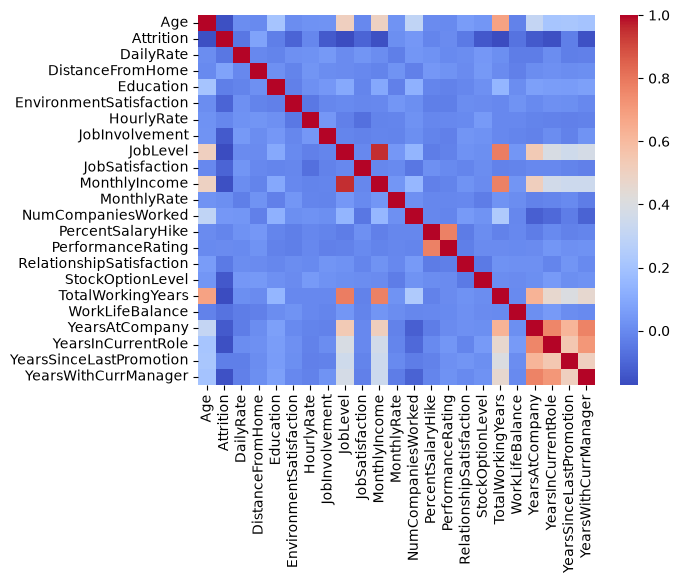

In [48]:
# Correlation Matrix
# -------------------------------------------

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=False,
            cmap='coolwarm')
plt.show()

**Encoding Categorical to numerical column**

In [49]:
# ======================================================
# Categorical Feature Encoding
# ======================================================

# Binary Categorical Feature (Label Encoding)
# ------------------------------------------------------
# 1. Gender      : Female, Male
# 2. Attrition   : Yes, No (Target Variable)
# 3. OverTime    : Yes, No

binary_columns = ['Attrition', 'Gender', 'OverTime']


# Nominal Categorical Feature (One hot Encoding)
# ------------------------------------------------------
# 1. BusinessTravel     : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
# 2. Department         : ['Sales' 'Research & Development' 'Human Resources']
# 3. EducationField     : ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree' 'Human Resources']
# 4. JobRole            : ['Sales Executive' 'Research Scientist' 'Laboratory Technician' 'Manufacturing Director' 'Healthcare Representative' 'Manager''Sales Representative' 'Research Director' 'Human Resources']
# 5. MaritalStatus      : ['Single' 'Married' 'Divorced']


Ont_hot_Encoding_columns = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'MaritalStatus',
    'JobRole'
]


In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Binary Encoding  (Label Encoding)

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

print(df.sample(4))

      Age  Attrition BusinessTravel  DailyRate              Department  \
1442   29          1  Travel_Rarely       1092  Research & Development   
173    30          0     Non-Travel        111  Research & Development   
195    37          0  Travel_Rarely        290  Research & Development   
852    29          0  Travel_Rarely       1401  Research & Development   

      DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
1442                 1          4        Medical                        1   
173                  9          3        Medical                        3   
195                 21          3  Life Sciences                        2   
852                  6          1        Medical                        2   

      Gender  ...  PercentSalaryHike  PerformanceRating  \
1442       1  ...                 14                  3   
173        1  ...                 11                  3   
195        1  ...                 12                  3   
852    

In [51]:
# One hot encoding

df = pd.get_dummies(
    df, 
    columns=Ont_hot_Encoding_columns,
    drop_first=True,
    dtype=int
)

print(df.sample(5))

      Age  Attrition  DailyRate  DistanceFromHome  Education  \
381    30          0        202                 2          1   
88     30          0        288                 2          3   
667    41          1       1085                 2          4   
1266   41          0        548                 9          4   
892    19          1        504                10          3   

      EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  \
381                         3       1          72               3         1   
88                          3       1          99               2         2   
667                         2       0          57               1         1   
1266                        3       1          94               3         1   
892                         1       0          96               2         1   

      ...  MaritalStatus_Married  MaritalStatus_Single  \
381   ...                      1                     0   
88    ...               

In [52]:
df.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_R

**Split the dataset**

In [53]:
# Splitting a dataset
from sklearn.model_selection import train_test_split
# print(df.head(2))
X = df.drop(columns=['Attrition'])
Y = df['Attrition']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [54]:
# print(X_train.sample(5))
X_train

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,MaritalStatus_Married,MaritalStatus_Single,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
1097,24,350,21,2,3,1,57,2,1,1,...,0,0,0,1,0,0,0,0,0,0
727,18,287,5,2,2,1,73,3,1,4,...,0,1,0,0,0,0,0,1,0,0
254,29,1247,20,2,4,1,45,3,2,4,...,0,0,0,0,0,0,0,0,1,0
1175,39,492,12,3,4,1,66,3,2,2,...,1,0,0,0,0,1,0,0,0,0
1341,31,311,20,3,2,1,89,3,2,3,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,35,750,28,3,2,1,46,4,2,3,...,1,0,0,1,0,0,0,0,0,0
1294,41,447,5,3,2,1,85,4,2,2,...,0,1,0,0,0,0,0,0,0,0
860,22,1256,3,4,3,1,48,2,1,4,...,1,0,0,0,0,0,0,1,0,0
1459,29,1378,13,2,4,1,46,2,2,2,...,1,0,0,1,0,0,0,0,0,0


# **Feature Scaling**

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)

[[-1.38855944 -1.10813858  1.44039645 ... -0.50901929 -0.52486957
  -0.26099788]
 [-2.04073779 -1.2634814  -0.52269928 ...  1.96456207 -0.52486957
  -0.26099788]
 [-0.84507748  1.10364737  1.31770296 ... -0.50901929  1.90523522
  -0.26099788]
 ...
 [-1.60595222  1.1258392  -0.76808624 ...  1.96456207 -0.52486957
  -0.26099788]
 [-0.84507748  1.42666182  0.45884859 ... -0.50901929 -0.52486957
  -0.26099788]
 [ 1.43754676 -1.32019386 -0.03192534 ... -0.50901929 -0.52486957
  -0.26099788]]


In [56]:
# Model where Feature scaling require
# -------------------------------------------------------
# SVM, 
# KNN, 
# Logistic Regression
# -------------------------------------------------------

# ======================================================= 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Model where No Feature scaling require
# -------------------------------------------------------
# Random Forest Classifier  
# Decision Tree
# -------------------------------------------------------

# ======================================================= 
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


ls = ['SVM', 'KNN', 'Logistic Regression', 'Random Forest Classifier', 'Decision Tree' ]

models = {
    "SVM" : {
        'name': 'SVM', 
        'model': SVC(kernel='linear', probability=True)
    },
    "KNN" : {
        'name': 'KNN', 
        'model': KNeighborsClassifier()
    },
    "Logistic Regression" : {
        'name': 'Logistic Regression', 
        'model': LogisticRegression()
    },
    "Random Forest Classifier" : {
        'name': 'Random Forest Classifier', 
        'model': RandomForestClassifier()
    },
    "Decision Tree" : { 
        'name': 'Decision Tree', 
        'model': DecisionTreeClassifier()
    }
}

for name in ls:
    model = models[name]['model']
    y_pred = None
    if(name in ['SVM', 'KNN', 'Logistic Regression']):
        model.fit(X_train_scaled, Y_train)      # Model Training
        y_pred = model.predict(X_test_scaled)   # Model Prediction
    else:
        model.fit(X_train, Y_train)     # Model Training
        y_pred = model.predict(X_test)  # Model Prediction

    print('model: ', name)
    accuracy = accuracy_score(y_pred, Y_test)
    f1 = f1_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)

    # print('Accuracy: ',accuracy_score(y_pred, Y_test))
    # print('F1 Score: ', f1_score(Y_test, y_pred))
    # print('Precision: ', precision_score(Y_test, y_pred))
    # print('Recall: ', recall_score(Y_test, y_pred))

    # eval = 0.4*row.F1 + 0.3*row.Recall + 0.3*row.Precision + 0.1*row.Accuracy
    
    overall_eval = 0.4*f1 + 0.3*recall + 0.2*precision + 0.1*accuracy 
    print(overall_eval)
    print('-'*200)

d:\Employee Attrition Prediction System Project\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


model:  SVM
0.5379253455365868
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
model:  KNN
0.4103192046049189
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
model:  Logistic Regression
0.5634798216368776
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
model:  Random Forest Classifier
0.32262864120006973
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
model:  Decision Tree
0.2619799857

In [57]:
# Shap Explainer object for every Explainer 
 
# for iter in models:
#     explainer = shap.TreeExplainer(iter['model'])
#     shape_values = explainer.shap_values(iter['test'])
#     print('Model: ', iter['name'])
#     shap.summary_plot(shape_values, iter['test'])
    

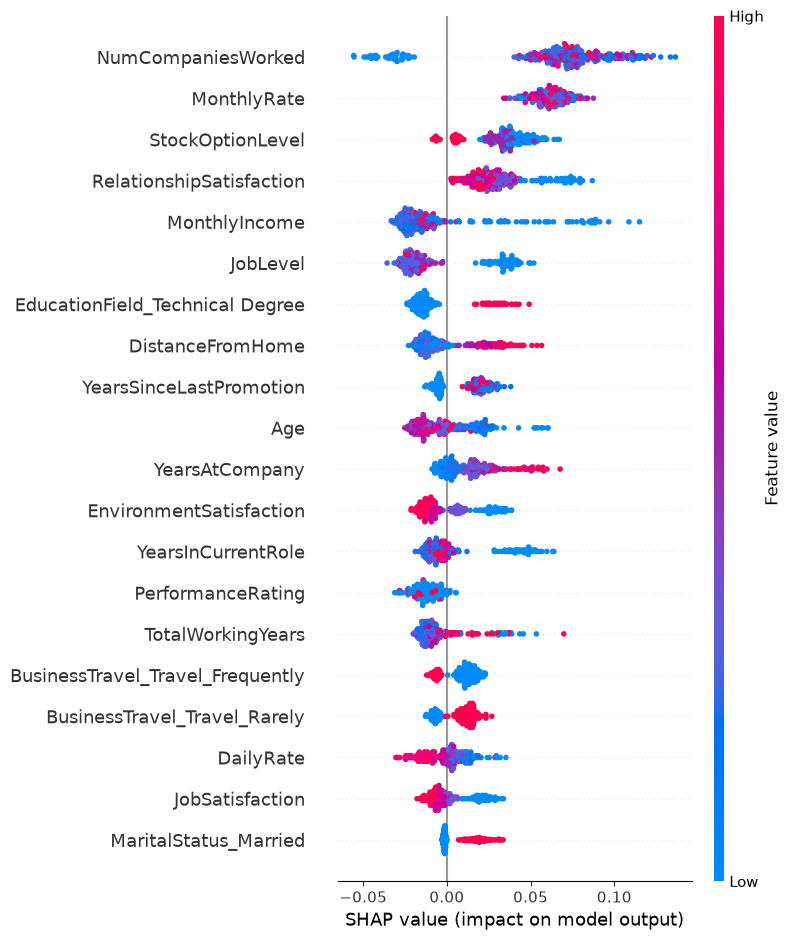

In [58]:
# Random Forest Explanation
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)
shap_class1 = shap_values[:,:,1]
# print(shap_values)
# print(shap_values.shape)
shap.summary_plot(shap_class1, X_test, feature_names=X_test.columns)

# ***Apply Deep Learning Now*** 

In [59]:
# Show pereprocessed dataframe

print(df.shape)

print(df.columns)

(1470, 44)
Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director',

Import Required Libraries

In [60]:
import sys

print(sys.executable)

d:\Employee Attrition Prediction System Project\venv\Scripts\python.exe


In [61]:
# %pip install tensorflow

Import Tensor Flow libraries

In [62]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential  

Create Neural Network

In [63]:
model = Sequential([
    layers.Input(shape=(X_train.shape[1], )),
    layers.Dense(16, activation='relu' ),
    layers.Dropout(0.3),
    # layers.Dense(16, activation='relu' ),
    # layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid' )
])

In [64]:
# Print Model Summary
print(model.summary())

# print(model.weights)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 721 (2.82 KB)

 Trainable params: 721 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

None


In [65]:
# Split the dataset : Already Done

# Scaled the dataset : Already Done


In [66]:
# print(X_train_scaled)

Compile the ANN Model

In [67]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Early Stopping

In [68]:
# Early Stopping
# ----------------------------------------------------------------------
from tensorflow.keras.callbacks import EarlyStopping

earlystopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Train the ANN Model

In [69]:
history = model.fit(X_train_scaled, Y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=earlystopping)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5915 - loss: 0.7340 - val_accuracy: 0.6356 - val_loss: 0.6750
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6713 - loss: 0.6418 - val_accuracy: 0.7288 - val_loss: 0.6150
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7245 - loss: 0.5805 - val_accuracy: 0.7924 - val_loss: 0.5762
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7649 - loss: 0.5479 - val_accuracy: 0.8008 - val_loss: 0.5477
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8053 - loss: 0.4910 - val_accuracy: 0.8051 - val_loss: 0.5218
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8234 - loss: 0.4580 - val_accuracy: 0.8093 - val_loss: 0.5054
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8309 - loss: 0.4429 - val_accuracy: 0.8093 - val_loss: 0.4942
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8309 - loss: 0.4275 - val_accuracy: 0.8093 - val_loss

# Plot a Visuals

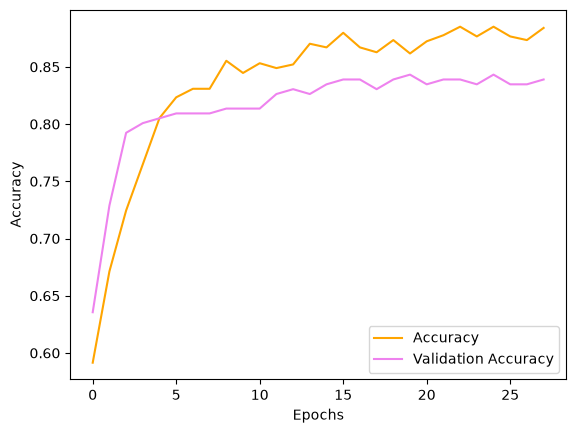

In [70]:
# Accuray Plot 

plt.plot(history.history['accuracy'], color='orange', label='Accuracy')
plt.plot(history.history['val_accuracy'],color='violet', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

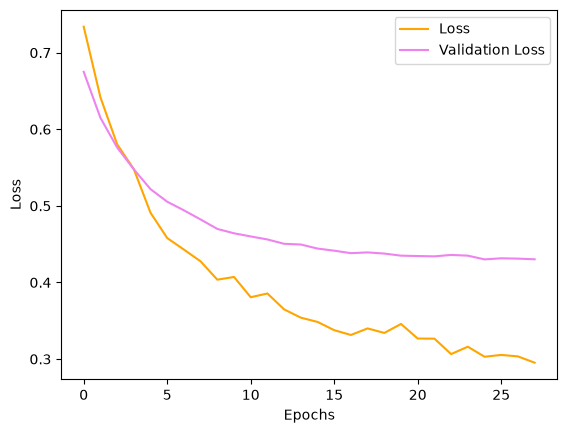

In [71]:
# Loss Graph 

plt.plot(history.history['loss'], color='orange', label='Loss')
plt.plot(history.history['val_loss'],color='violet', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()